# Ciclo de Operación de un Reactor Nuclear
## Simulación con COBAYA y CTF

**Máster en Tecnología de Reactores Nucleares — UPM**

---

Este libro interactivo describe y simula el **ciclo de operación completo de un reactor nuclear de pequeña potencia modular (SMR)** del tipo NuScale, integrando herramientas de cálculo neutrónico y termohidráulico.

### Estructura del libro

| Notebook | Tema |
|---|---|
| `00` | Introducción: el reactor NuScale y el ciclo de operación |
| `01` | Neutrónica: distribuciones de potencia con COBAYA |
| `02` | Termohidráulica: perfiles de temperatura con CTF |
| `03` | Acoplamiento neutrónico-termohidráulico |
| `04` | Deplección y gestión del ciclo de combustible |


---
## 1. El reactor NuScale SMR

### 1.1 Descripción general

El **NuScale Power Module (NPM)** es un reactor de agua a presión (PWR) de pequeña potencia modular diseñado por NuScale Power LLC. Sus características principales son:

| Parámetro | Valor |
|---|---|
| Potencia térmica nominal | 160 MWt (250 MWt en versión actualizada) |
| Potencia eléctrica | ~77 MWe |
| Presión del primario | 12.76 MPa |
| Temperatura de salida del refrigerante | ~320 °C |
| Número de ensamblajes de combustible | 37 |
| Duración del ciclo | ~24 meses |
| Diseño | Integral (presionador y generador de vapor integrados) |
| Circulación | Natural (sin bombas de refrigerante) |

### 1.2 Características de diseño

El NuScale destaca por su diseño **integral**: el presionador, los generadores de vapor helicoidales y el núcleo se encuentran dentro de un único recipiente de presión. Esto elimina las tuberías del circuito primario y reduce el riesgo de grandes roturas de tubería (LOCA).

La **circulación natural** del refrigerante primario (sin bombas) simplifica el sistema y mejora la seguridad pasiva: el reactor puede enfriarse por convección natural indefinidamente sin energía eléctrica externa.

### 1.3 Núcleo del reactor

El núcleo contiene **37 ensamblajes de combustible** de diseño estándar para PWR (17×17 varillas), con las siguientes características:

- Enriquecimiento máximo: ~4.95% en U-235
- Presencia de venenos combustibles (IFBA o Gd₂O₃) para controlar la reactividad inicial
- 16 posiciones de barras de control en el núcleo
- Sin boro en el refrigerante en operación normal (control por barras y venenos combustibles)


---
## 2. El ciclo de operación

### 2.1 Fases del ciclo

El ciclo de operación de un reactor nuclear puede describirse en las siguientes fases:

```
INICIO DE CICLO (BOC)
       │
       ▼
  ARRANQUE DEL REACTOR
  ─ Criticidad con barras de control
  ─ Quema inicial de venenos (Xe, Sm)
       │
       ▼
  OPERACIÓN A PLENA POTENCIA
  ─ Distribución de potencia neutrónica
  ─ Perfiles T refrigerante / T combustible
  ─ Retroalimentación neutrónica-TH
       │
       ▼
  DEPLECCIÓN DEL COMBUSTIBLE (~24 meses)
  ─ Evolución de k_eff (compensada con barras)
  ─ Acumulación de productos de fisión
  ─ Generación de Pu-239 por captura en U-238
       │
       ▼
  FIN DE CICLO (EOC)
  ─ Parada del reactor
  ─ Recarga parcial de combustible
       │
       └──► Nuevo ciclo
```

### 2.2 Magnitudes clave

Durante el ciclo monitorizamos las siguientes magnitudes físicas:

**Neutrónica:**
- Factor de multiplicación efectivo $k_{eff}$ (condición de criticidad: $k_{eff} = 1$)
- Distribución radial de potencia: $P(x,y)$
- Distribución axial de potencia: $P(z)$
- Factor de forma axial: $F_z = P_{max}/P_{media}$
- Factores de pico de potencia: $F_q$, $F_{\Delta H}$

**Termohidráulica:**
- Temperatura del refrigerante: $T_{ref}(z)$
- Temperatura del combustible: $T_{fuel}(z)$
- Temperatura de la vaina (cladding): $T_{clad}(z)$
- Relación de Flujo Neto de Ebullición (DNBR): criterio de seguridad

**Deplección:**
- Quemado (burnup): GWd/tU
- Evolución de isótopos: U-235, U-238, Pu-239, Xe-135, Sm-149


---
## 3. Herramientas de simulación

### 3.1 COBAYA — Código neutrónico

**COBAYA** (COde for Best-estimate Analysis of Neutronics) es un código de cálculo neutrónico desarrollado en el CIEMAT (Centro de Investigaciones Energéticas, Medioambientales y Tecnológicas).

Resuelve la **ecuación de difusión de neutrones** en 3D para reactores de agua ligera:

$$-\nabla \cdot D(\vec{r}) \nabla \phi(\vec{r}) + \Sigma_a(\vec{r}) \phi(\vec{r}) = \frac{1}{k_{eff}} \nu \Sigma_f(\vec{r}) \phi(\vec{r})$$

**Archivos de entrada/salida:**
- Entrada: archivos de secciones eficaces (`.CON`) por ensamblaje
- Salida: distribuciones de flujo y potencia normalizadas

**Casos simulados en la Práctica 1:**
- **REF**: caso de referencia (condiciones nominales)
- **SIM**: caso con composición modificada en algún ensamblaje
- **VAC**: caso con núcleo parcialmente vaciado (void)

### 3.2 CTF — Código termohidráulico

**CTF** (COBRA-TF) es un código de análisis termohidráulico por subcanales para núcleos de reactores de agua ligera, desarrollado por la Universidad Estatal de Carolina del Norte y Westinghouse.

Resuelve las ecuaciones de conservación de masa, momento y energía para una malla de subcanales:

$$\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \vec{u}) = 0 \qquad \text{(conservación de masa)}$$

$$\frac{\partial (\rho h)}{\partial t} + \nabla \cdot (\rho h \vec{u}) = q''' + \nabla \cdot (k \nabla T) \qquad \text{(energía)}$$

**Archivos de salida analizados:**
- `channels.out`: temperaturas y flujos por canal y cota axial
- `cpld_temp_dens_summary.out`: resumen acoplado temperatura-densidad

### 3.3 Flujo de trabajo del libro

```
Secciones eficaces
(archivos .CON)         ┌─────────┐    Distribución de potencia
        ──────────────► │  COBAYA │ ──────────────────────────────►
                        └─────────┘                               │
                                                                  │
                                              ┌────────────────── ┘
                                              │
                                              ▼
                                        ┌─────────┐    Temperatura
  Parámetros TH del canal  ────────────►│   CTF   │ ──► refrigerante
                                        └─────────┘    Temperatura
                                              │         combustible
                                              │         DNBR
                                              ▼
                              Retroalimentación → nuevas secciones eficaces
                              (acoplamiento iterativo COBAYA ↔ CTF)
```


---
## 4. Configuración del entorno


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import sys

# Configuración global de gráficas
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

print(f"Python {sys.version}")
print(f"NumPy {np.__version__}, Pandas {pd.__version__}, Matplotlib {plt.matplotlib.__version__}")

Python 3.12.4 (tags/v3.12.4:8e8a4ba, Jun  6 2024, 19:30:16) [MSC v.1940 64 bit (AMD64)]
NumPy 2.4.2, Pandas 3.0.1, Matplotlib 3.10.8


In [2]:
# ============================================================
# CONFIGURACIÓN DE RUTAS — Ajusta DATA_ROOT a tu entorno
# ============================================================
DATA_ROOT = pathlib.Path(
    r"C:\Users\pablo\OneDrive - Universidad Politécnica de Madrid\THN\Prácticas"
)

P1 = DATA_ROOT / "Practica 1"   # Archivos COBAYA
P2 = DATA_ROOT / "Practica 2"   # Outputs CTF

# Verificar rutas
for label, path in [("DATA_ROOT", DATA_ROOT), ("Practica 1", P1), ("Practica 2", P2)]:
    status = "✓" if path.exists() else "✗ NO ENCONTRADA"
    print(f"{label}: {status}")
    print(f"  {path}")

DATA_ROOT: ✓
  C:\Users\pablo\OneDrive - Universidad Politécnica de Madrid\THN\Prácticas
Practica 1: ✓
  C:\Users\pablo\OneDrive - Universidad Politécnica de Madrid\THN\Prácticas\Practica 1
Practica 2: ✓
  C:\Users\pablo\OneDrive - Universidad Politécnica de Madrid\THN\Prácticas\Practica 2


---
## 5. Vista previa del núcleo NuScale

El núcleo del NuScale tiene geometría hexagonal truncada con 37 ensamblajes de combustible en disposición aproximadamente circular. A continuación se muestra un esquema simplificado.


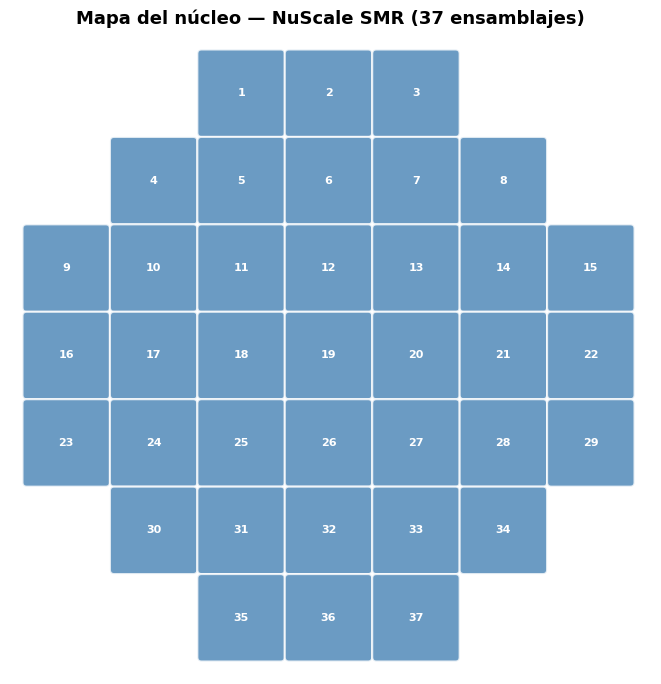

Total ensamblajes: 37


In [3]:
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# Posiciones de los 37 ensamblajes en coordenadas (fila, columna)
# Núcleo NuScale: disposición aproximada 7x7 con esquinas recortadas
core_map = [
    # (fila, col) para cada ensamblaje
    (0,2),(0,3),(0,4),
    (1,1),(1,2),(1,3),(1,4),(1,5),
    (2,0),(2,1),(2,2),(2,3),(2,4),(2,5),(2,6),
    (3,0),(3,1),(3,2),(3,3),(3,4),(3,5),(3,6),
    (4,0),(4,1),(4,2),(4,3),(4,4),(4,5),(4,6),
    (5,1),(5,2),(5,3),(5,4),(5,5),
    (6,2),(6,3),(6,4),
]

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

# Dibujar ensamblajes
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(core_map)))
for i, (row, col) in enumerate(core_map):
    rect = mpatches.FancyBboxPatch(
        (col * 1.05, (6 - row) * 1.05), 0.95, 0.95,
        boxstyle="round,pad=0.05",
        facecolor='steelblue', edgecolor='white', linewidth=1.5,
        alpha=0.8
    )
    ax.add_patch(rect)
    ax.text(col * 1.05 + 0.475, (6 - row) * 1.05 + 0.475, str(i+1),
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_xlim(-0.2, 7.5)
ax.set_ylim(-0.2, 7.5)
ax.set_aspect('equal')
ax.set_title('Mapa del núcleo — NuScale SMR (37 ensamblajes)', fontsize=13, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()
print(f"Total ensamblajes: {len(core_map)}")

---
## 6. Resumen y próximos pasos

En este notebook de introducción hemos:

1. Descrito las características físicas del reactor NuScale SMR
2. Explicado las fases del ciclo de operación
3. Presentado las herramientas de simulación COBAYA y CTF
4. Configurado las rutas de datos

**Continúa en:**
- `01_neutronics_cobaya.ipynb` → Análisis de distribuciones de potencia con COBAYA
